In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


mobility_og = pd.read_csv("../data/mobility_va.csv")
mobility_og['date'] = pd.to_datetime(mobility_og['date'])


mobility = pd.read_csv("../data/mobility_clean.csv")
mobility['date'] = pd.to_datetime(mobility['date'])

mobility_features = ['retail_and_recreation_percent_change_from_baseline',
                     'grocery_and_pharmacy_percent_change_from_baseline',
                     'transit_stations_percent_change_from_baseline',
                     'workplaces_percent_change_from_baseline',
                     'residential_percent_change_from_baseline']

print(mobility_og.columns)
print(f"\n{mobility_og.shape}")
print(f"\n{mobility_og['date'].min()}")
print(f"\n{mobility_og['date'].max()}")


Index(['Unnamed: 0', 'country_region_code', 'country_region', 'sub_region_1',
       'sub_region_2', 'metro_area', 'iso_3166_2_code', 'census_fips_code',
       'place_id', 'date',
       'retail_and_recreation_percent_change_from_baseline',
       'grocery_and_pharmacy_percent_change_from_baseline',
       'parks_percent_change_from_baseline',
       'transit_stations_percent_change_from_baseline',
       'workplaces_percent_change_from_baseline',
       'residential_percent_change_from_baseline'],
      dtype='str')

(116956, 16)

2020-02-15 00:00:00

2022-10-15 00:00:00


/var/folders/lv/9m_qv53944x04_1mpk21jgtc0000gn/T/ipykernel_92343/1144750268.py:8: DtypeWarning: Columns (0: iso_3166_2_code) have mixed types. Specify dtype option on import or set low_memory=False.
  mobility_og = pd.read_csv("../data/mobility_va.csv")


<Axes: >

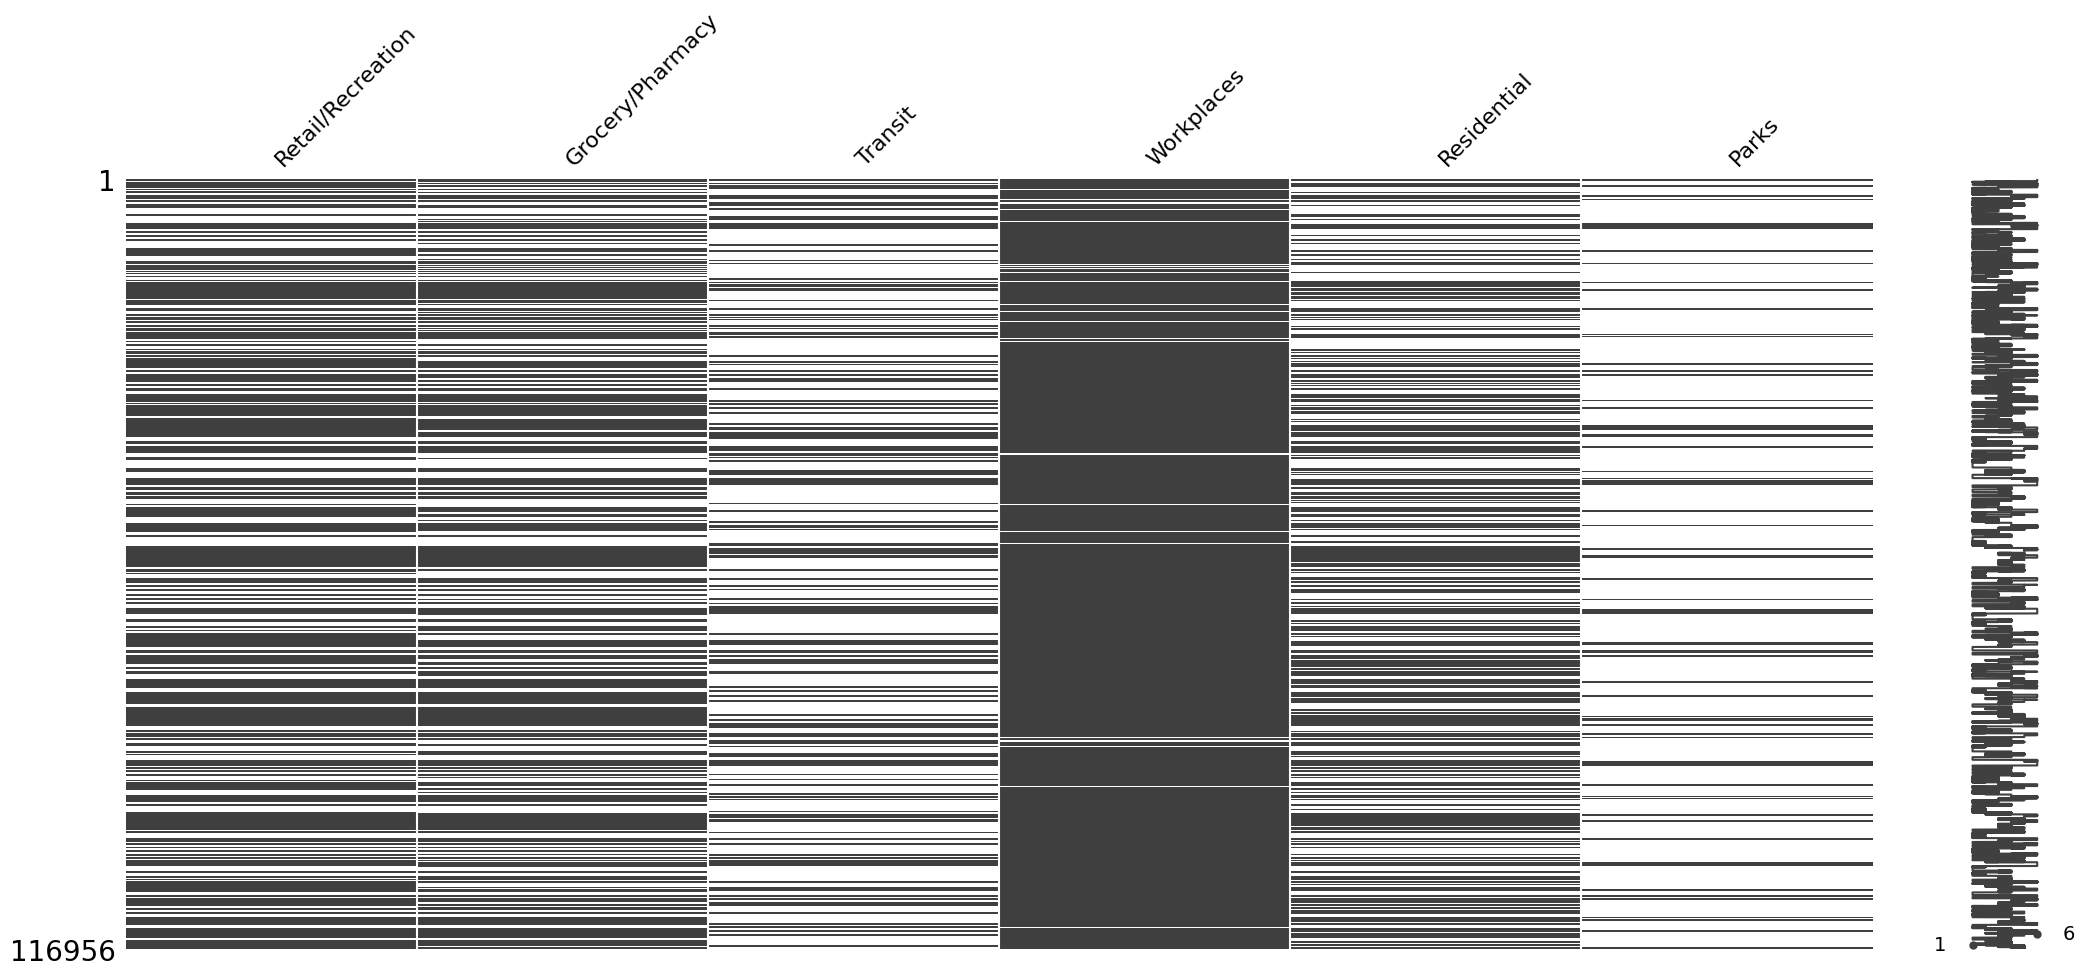

In [6]:
mobility_og.rename(columns={
    'retail_and_recreation_percent_change_from_baseline':'Retail/Recreation', 
    'grocery_and_pharmacy_percent_change_from_baseline':'Grocery/Pharmacy',
    'transit_stations_percent_change_from_baseline':'Transit',
    'workplaces_percent_change_from_baseline':'Workplaces',
    'residential_percent_change_from_baseline':'Residential', 
    'parks_percent_change_from_baseline':'Parks'
}, inplace=True)

short_features=['Retail/Recreation', 'Grocery/Pharmacy', 'Transit', 'Workplaces', 'Residential', 'Parks']
msno.matrix(mobility_og[short_features])


In [7]:
# summary stats
described = pd.DataFrame(mobility[mobility_features].describe().T)
described = described.rename(columns={'50%': 'median'})  # fix rename
described = round(described, 2)
display(described)

# LaTeX export
latex_table = described.to_latex(float_format="%.2f", index=True)
print("\\begin{table}[ht]\n\\centering")
print(latex_table)
print("\\caption{Descriptive statistics for mobility features.}")
print("\\label{tab:mobility_descriptives}")
print("\\end{table}")


,count,mean,std,min,25%,median,75%,max
retail_and_recreation_percent_change_from_baseline,33013.0,-11.51,16.59,-95.0,-20.0,-11.0,-2.0,114.0
grocery_and_pharmacy_percent_change_from_baseline,33013.0,0.69,14.39,-92.0,-8.0,0.0,8.0,100.0
transit_stations_percent_change_from_baseline,33013.0,-19.09,33.18,-86.0,-44.0,-22.0,0.0,246.0
workplaces_percent_change_from_baseline,33013.0,-26.48,16.38,-91.0,-37.0,-26.0,-15.0,18.0
residential_percent_change_from_baseline,33013.0,7.72,5.99,-5.0,4.0,7.0,11.0,40.0


\begin{table}[ht]
\centering
\begin{tabular}{lrrrrrrrr}
\toprule
 & count & mean & std & min & 25% & median & 75% & max \\
\midrule
retail_and_recreation_percent_change_from_baseline & 33013.00 & -11.51 & 16.59 & -95.00 & -20.00 & -11.00 & -2.00 & 114.00 \\
grocery_and_pharmacy_percent_change_from_baseline & 33013.00 & 0.69 & 14.39 & -92.00 & -8.00 & 0.00 & 8.00 & 100.00 \\
transit_stations_percent_change_from_baseline & 33013.00 & -19.09 & 33.18 & -86.00 & -44.00 & -22.00 & 0.00 & 246.00 \\
workplaces_percent_change_from_baseline & 33013.00 & -26.48 & 16.38 & -91.00 & -37.00 & -26.00 & -15.00 & 18.00 \\
residential_percent_change_from_baseline & 33013.00 & 7.72 & 5.99 & -5.00 & 4.00 & 7.00 & 11.00 & 40.00 \\
\bottomrule
\end{tabular}

\caption{Descriptive statistics for mobility features.}
\label{tab:mobility_descriptives}
\end{table}


In [ ]:
# Abbreviate long feature names for table readability
feature_map = {
    "retail_and_recreation_percent_change_from_baseline": "Retail/Rec",
    "grocery_and_pharmacy_percent_change_from_baseline": "Grocery/Pharm",
    "transit_stations_percent_change_from_baseline": "Transit",
    "workplaces_percent_change_from_baseline": "Workplaces",
    "residential_percent_change_from_baseline": "Residential"
}

# Compute only the key statistics: mean, std, median, Q1, Q3
described = mobility[mobility_features].agg(['mean', 'std', 'median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])
described = described.rename(index={'<lambda_0>':'Q1','<lambda_1>':'Q3'})  # rename lambda columns
described = described.round(2)  # round to 2 decimals
described.index = ['Mean', 'Std', 'Median', 'Q1', 'Q3']  # nicer index labels

# Transpose so rows = features, columns = stats
described = described.T
described.index = described.index.map(feature_map)

latex_table = described.to_latex(
    float_format="%.2f",
    index=True,
    caption="Key descriptive statistics for mobility features.",
    label="tab:key_stats",
)

print(latex_table)



\begin{table}
\caption{Key descriptive statistics for mobility features.}
\label{tab:key_stats}
\begin{tabular}{lrrrrr}
\toprule
 & Mean & Std & Median & Q1 & Q3 \\
\midrule
Retail/Rec & -11.51 & 16.59 & -11.00 & -20.00 & -2.00 \\
Grocery/Pharm & 0.69 & 14.39 & 0.00 & -8.00 & 8.00 \\
Transit & -19.09 & 33.18 & -22.00 & -44.00 & 0.00 \\
Workplaces & -26.48 & 16.38 & -26.00 & -37.00 & -15.00 \\
Residential & 7.72 & 5.99 & 7.00 & 4.00 & 11.00 \\
\bottomrule
\end{tabular}
\end{table}



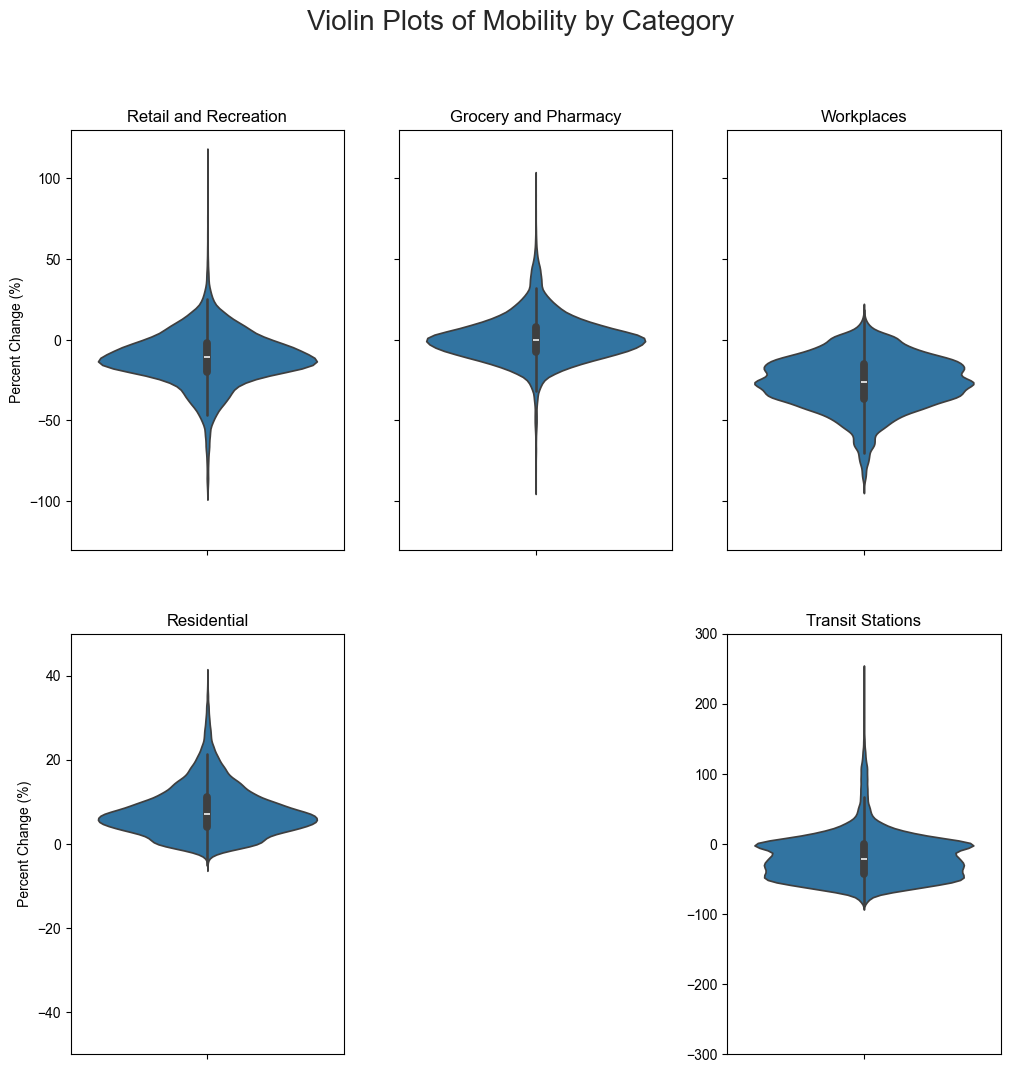

In [24]:
# violin plots

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 12))

sns.set_style("darkgrid")

sns.violinplot(y=mobility["retail_and_recreation_percent_change_from_baseline"], ax=axes[0, 0])
sns.violinplot(y=mobility["grocery_and_pharmacy_percent_change_from_baseline"], ax=axes[0, 1])
sns.violinplot(y=mobility["transit_stations_percent_change_from_baseline"], ax=axes[1, 2])
sns.violinplot(y=mobility["workplaces_percent_change_from_baseline"], ax=axes[0, 2])
sns.violinplot(y=mobility["residential_percent_change_from_baseline"], ax=axes[1, 0])

for ax in [axes[0, 0], axes[1, 0]]: 
    ax.set_ylabel("Percent Change (%)")

for ax in [axes[0, 1], axes[0, 2]]: 
    ax.set_ylabel('')
    ax.set_yticklabels([])

for ax in axes.flatten(): 
    ax.set_ylim(-130, 130)

axes[1, 2].set_ylim(-300, 300)
axes[1, 2].set_ylabel('')

axes[1, 0].set_ylim(-50, 50)

axes[0, 0].set_title("Retail and Recreation")
axes[0, 1].set_title("Grocery and Pharmacy")
axes[1, 2].set_title("Transit Stations")
axes[0, 2].set_title("Workplaces")
axes[1, 0].set_title("Residential")

fig.suptitle("Violin Plots of Mobility by Category", fontsize=20)

fig.delaxes(axes[1, 1])